```text
=============================================================================
 myBytes.com  ·  Research notebook
 Copyright (c) 2026 myBytes GmbH. All rights reserved.
=============================================================================
```

# Size recommendation for multi-size fashion orders, honestly measured

Companion research notebook to the myBytes note
*"Was Retouren in Mode wirklich kosten, und ob sich Vorhersage lohnt"*
([mybytes.com/research/fashion-returns-prevention](https://mybytes.com/research/fashion-returns-prevention)),
size-recommendation lever.

A common vendor claim is that personalised size recommendation cuts returns by
25 %. We test the mechanism on the **Data Mining Cup 2016** dataset (2,325,165
line items). Customers order the same article in several sizes ("size
bracketing"), keep one, return the rest. The mechanism is real, the lever is
smaller than advertised. Scopes are labelled throughout: bracket prevalence is
measured on the **full dataset**, recommender performance on a **leak-free
temporal test split**.

Data is not shipped (Kaggle / competition terms); see `DATA.md`.

## 1 · Setup and data

We keep the columns the bracketing analysis needs and derive two flags:
`ret` (the line item was returned) and `kept` (it was not fully returned).

In [1]:
import glob
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_orders() -> str:
    for pat in [str(Path.cwd().parent / "data/raw/*.txt"),
                str(Path.home() / ".cache/kagglehub/**/orders_train.txt")]:
        hits = sorted(glob.glob(pat, recursive=True))
        if hits:
            return hits[0]
    raise FileNotFoundError("orders_train.txt not found — see DATA.md")


cols = ["orderID", "orderDate", "articleID", "productGroup", "sizeCode",
        "quantity", "returnQuantity", "customerID"]
df = pd.read_csv(find_orders(), sep=";", usecols=cols)
df["orderDate"] = pd.to_datetime(df["orderDate"], errors="coerce")
df = df.dropna(subset=["orderDate"]).sort_values("orderDate").reset_index(drop=True)
df["kept"] = (df["returnQuantity"] < df["quantity"]).astype(int)
df["ret"] = (df["returnQuantity"] > 0).astype(int)
print(f"{len(df):,} line items   overall return rate {df['ret'].mean():.1%}")

2,325,165 line items   overall return rate 52.0%


## 2 · Size brackets in the full dataset

A **size bracket** is the same `orderID` + `articleID` ordered in two or more
different sizes. These are where size-driven returns live — and they are a large,
return-heavy slice of the business.

In [2]:
nuniq = df.groupby(["orderID", "articleID"])["sizeCode"].transform("nunique")
df["in_bracket"] = nuniq >= 2

share_items = df["in_bracket"].mean()
ret_in_bracket = df.loc[df["in_bracket"], "ret"].mean()
share_of_returns = df.loc[df["in_bracket"], "ret"].sum() / df["ret"].sum()
print("scope: FULL dataset")
print(f"size brackets as share of all line items : {share_items:.1%}")
print(f"return rate inside brackets              : {ret_in_bracket:.0%}")
print(f"brackets as share of ALL returns         : {share_of_returns:.1%}")

scope: FULL dataset
size brackets as share of all line items : 16.6%
return rate inside brackets              : 73%
brackets as share of ALL returns         : 23.5%


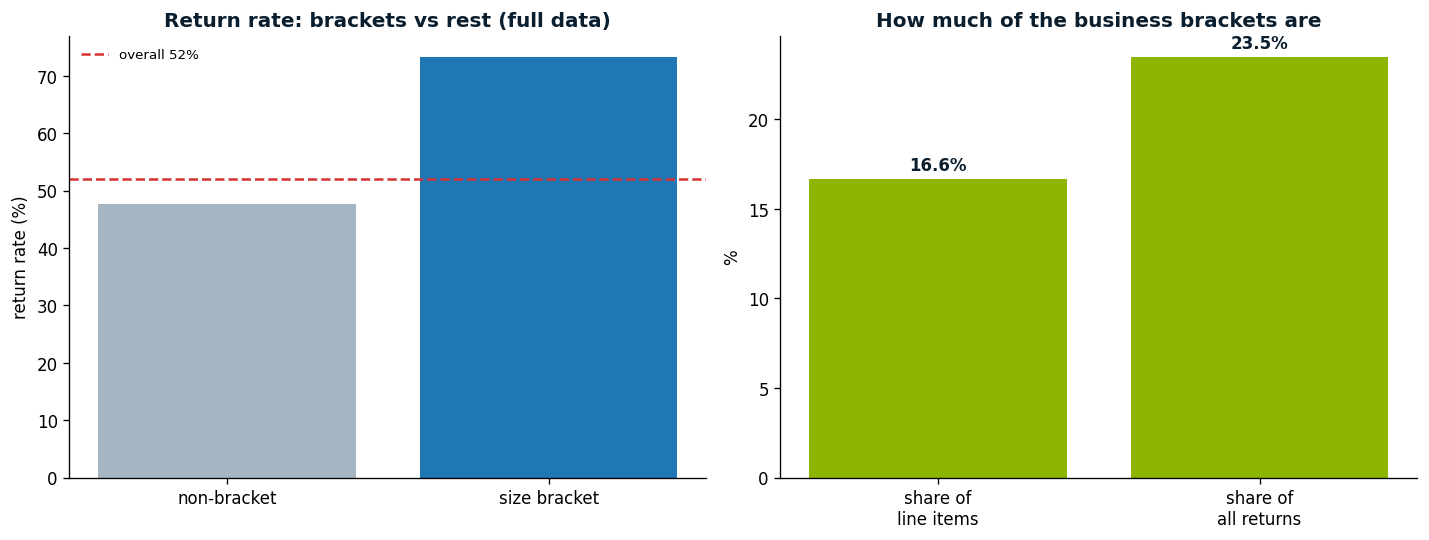

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
INK, C1, C2, GREY = "#0a1e2e", "#1f77b4", "#8eb600", "#A6B5C2"
base = df["ret"].mean()
ax[0].bar(["non-bracket", "size bracket"],
          [df.loc[~df["in_bracket"], "ret"].mean() * 100, ret_in_bracket * 100],
          color=[GREY, C1])
ax[0].axhline(base * 100, ls="--", color="#d63031", label=f"overall {base:.0%}")
ax[0].set_title("Return rate: brackets vs rest (full data)", fontweight="bold", color=INK)
ax[0].set_ylabel("return rate (%)"); ax[0].legend(frameon=False, fontsize=8)
ax[1].bar(["share of\nline items", "share of\nall returns"],
          [share_items * 100, share_of_returns * 100], color=C2)
for i, v in enumerate([share_items, share_of_returns]):
    ax[1].text(i, v * 100 + 0.5, f"{v:.1%}", ha="center", fontweight="bold", color=INK)
ax[1].set_title("How much of the business brackets are", fontweight="bold", color=INK)
ax[1].set_ylabel("%")
for a in ax:
    for sp in ("top", "right"):
        a.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()

So roughly one in six line items is a size bracket, those return at ~73 %, and
they account for ~24 % of all returns. That is the addressable *surface*. But not
all of it is a size problem.

## 3 · What is actually addressable

Only brackets where **exactly one** size is kept are a genuine size problem — get
that size right up front and the extra returns vanish. Brackets where **nothing**
is kept are a product or taste problem no size model can fix.

In [4]:
bk = (df[df["in_bracket"]].groupby(["orderID", "articleID"])
        .agg(n_kept=("kept", "sum")).reset_index())
keep_dist = bk["n_kept"].value_counts(normalize=True).sort_index()
print("scope: FULL dataset, distribution over brackets by #sizes kept")
for k in [0, 1, 2, 3]:
    if k in keep_dist.index:
        tag = "  <- addressable (size problem)" if k == 1 else ""
        print(f"  keep {k}: {keep_dist[k]:.1%}{tag}")

scope: FULL dataset, distribution over brackets by #sizes kept
  keep 0: 51.4%
  keep 1: 40.4%  <- addressable (size problem)
  keep 2: 6.9%
  keep 3: 1.0%


About half of all brackets keep nothing (not a size problem); about 40 % keep
exactly one size — that is the slice a recommender can actually act on.

## 4 · A leak-free size recommender

We split temporally (oldest 75 % train, newest 25 % test). The recommender learns
each customer's typical kept size per product group from **past** orders only,
falls back to the article's most-kept size, then a global default. We score it on
the addressable test brackets (exactly one kept): does it name the size the
customer actually kept?

In [5]:
cut = int(len(df) * 0.75)
tr, te = df.iloc[:cut], df.iloc[cut:]
kept_tr = tr[tr["kept"] == 1]


def modal_map(d, keys):
    return d.groupby(keys)["sizeCode"].agg(lambda s: Counter(s).most_common(1)[0][0]).to_dict()


cust_pg = modal_map(kept_tr, ["customerID", "productGroup"])
art_mode = modal_map(kept_tr, ["articleID"])
global_mode = Counter(kept_tr["sizeCode"]).most_common(1)[0][0]


def recommend(cust, pg, art, personalized=True):
    if personalized and (cust, pg) in cust_pg:
        return cust_pg[(cust, pg)]
    return art_mode.get(art, global_mode)


total_test_returns = int(te["ret"].sum())
rows = []
for (oid, art), grp in te.groupby(["orderID", "articleID"]):
    if grp["sizeCode"].nunique() < 2:
        continue
    kept_sizes = grp.loc[grp["kept"] == 1, "sizeCode"].tolist()
    rows.append({"n_kept": len(kept_sizes),
                 "kept_size": kept_sizes[0] if len(kept_sizes) == 1 else None,
                 "ret_items": int(grp["ret"].sum()),
                 "rec_pers": recommend(grp["customerID"].iloc[0], grp["productGroup"].iloc[0], art, True),
                 "rec_base": recommend(grp["customerID"].iloc[0], grp["productGroup"].iloc[0], art, False)})
b = pd.DataFrame(rows)
addr = b[b["n_kept"] == 1].copy()
addr["hit_pers"] = (addr["rec_pers"] == addr["kept_size"]).astype(int)
addr["hit_base"] = (addr["rec_base"] == addr["kept_size"]).astype(int)

addressable_returns = int(addr["ret_items"].sum())
captured_pers = int(addr.loc[addr["hit_pers"] == 1, "ret_items"].sum())
hit_pers, hit_base = addr["hit_pers"].mean(), addr["hit_base"].mean()
ceiling = addressable_returns / total_test_returns
captured = captured_pers / total_test_returns

print("scope: TEMPORAL TEST split (newest 25%)")
print(f"addressable brackets (keep exactly 1): {len(addr):,}")
print(f"hit rate, personalized recommender   : {hit_pers:.1%}")
print(f"hit rate, article-only baseline      : {hit_base:.1%}")
print(f"ceiling (addressable share of all returns): {ceiling:.1%}")
print(f"realistically captured (personalized): {captured:.1%} of all returns")

scope: TEMPORAL TEST split (newest 25%)
addressable brackets (keep exactly 1): 17,352
hit rate, personalized recommender   : 28.8%
hit rate, article-only baseline      : 19.1%
ceiling (addressable share of all returns): 6.9%
realistically captured (personalized): 2.0% of all returns


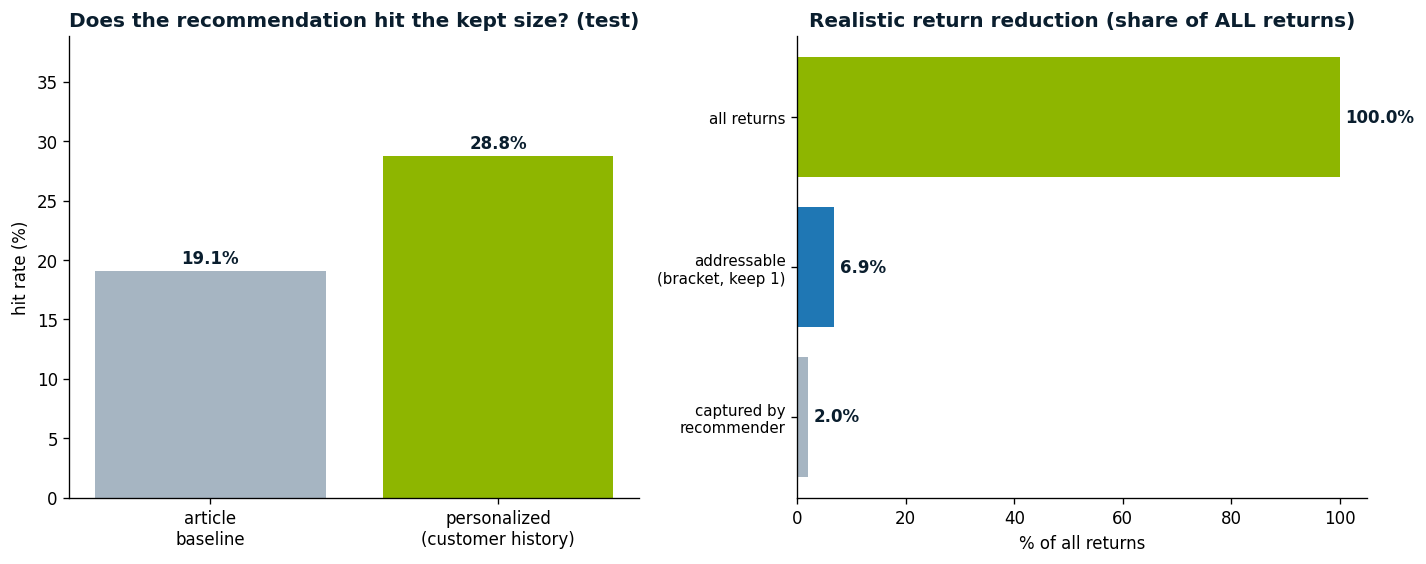

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
INK, C1, C2, GREY = "#0a1e2e", "#1f77b4", "#8eb600", "#A6B5C2"
ax[0].bar(["article\nbaseline", "personalized\n(customer history)"],
          [hit_base * 100, hit_pers * 100], color=[GREY, C2])
for i, v in enumerate([hit_base, hit_pers]):
    ax[0].text(i, v * 100 + 0.6, f"{v:.1%}", ha="center", fontweight="bold", color=INK)
ax[0].set_title("Does the recommendation hit the kept size? (test)", fontweight="bold", color=INK)
ax[0].set_ylabel("hit rate (%)"); ax[0].set_ylim(0, max(hit_pers, hit_base) * 135)
fr = [1.0, ceiling, captured]
lab = ["all returns", "addressable\n(bracket, keep 1)", "captured by\nrecommender"]
ax[1].barh(range(3), [f * 100 for f in fr][::-1], color=[C2, C1, GREY][::-1])
ax[1].set_yticks(range(3)); ax[1].set_yticklabels(lab[::-1], fontsize=9)
for i, f in enumerate(fr[::-1]):
    ax[1].text(f * 100 + 1, i, f"{f:.1%}", va="center", fontweight="bold", color=INK)
ax[1].set_title("Realistic return reduction (share of ALL returns)", fontweight="bold", color=INK)
ax[1].set_xlabel("% of all returns"); ax[1].set_xlim(0, 105)
for a in ax:
    for sp in ("top", "right"):
        a.spines[sp].set_visible(False)
fig.tight_layout(); plt.show()

## Conclusion

- Size brackets are **~16.6 %** of line items, return at **~73 %**, and make up
  **~23.5 %** of all returns (full dataset) — a real, return-heavy surface.
- But only ~40 % of brackets keep exactly one size; the rest are not a size
  problem. The personalised recommender hits the kept size **28.8 %** of the time
  vs **19.1 %** for an article-only baseline — clearly better, genuinely learned.
- Realistically it captures **~2 %** of all returns, with a hard ceiling near
  **6.9 %** (test split). Personalisation works; the 25 % claim is not reachable
  with size recommendation alone.

Method and data licensing: see `LICENSES.md`. Methodological research on a public
dataset, not business advice.